# Projet Détection de fraude par carte bancaire
### Dataset : Credit Card Fraud Detection

## 01_import_libraries

In [1]:
#!pip install pathlib2
#!pip install kagglehub
#!pip install python-dotenv
#!pip install pandas
#!pip install matplotlib 
#!pip install seaborn

In [2]:
from pathlib import Path
from dotenv import load_dotenv
import os
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\youna\Desktop\4IIR\s8\Exploration De Données\Projet\Ma_realisation\DataMining_CreditCardFraud\.venvCreditCard\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 02_load_dataset : chargement du dataset et preuve de la source.

## Source du dataset

Le dataset utilisé est **Credit Card Fraud Detection**, disponible sur Kaggle.

- Source officielle : Kaggle
- Lien : https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
- Fichier utilisé : `creditcard.csv`
- Domaine : finance / détection de fraude bancaire


In [3]:
# ==============================================================================
# 0. CONFIGURATION DE L'AUTHENTIFICATION KAGGLE
# ==============================================================================
env_path = Path(".").resolve().parent / ".env"
if env_path.exists():
    load_dotenv(dotenv_path=env_path)
    print("=> Variables d'environnement chargées depuis .env")

KAGGLE_USERNAME = os.getenv("KAGGLE_USERNAME")
KAGGLE_KEY = os.getenv("KAGGLE_KEY")

if not KAGGLE_USERNAME or not KAGGLE_KEY:
    print("=> Variables d'environnement KAGGLE_USERNAME ou KAGGLE_KEY manquantes.")

# ==============================================================================
# 1. DÉFINITION DES CHEMINS (Chemins absolus générés dynamiquement)
# ==============================================================================

NOTEBOOK_PATH = Path(".").resolve()
PROJECT_PATH = NOTEBOOK_PATH.parent
DATA_PATH = PROJECT_PATH / "data"
FIGURES_PATH = PROJECT_PATH / "figures"
CSV_FILE_PATH = DATA_PATH / "creditcard.csv"

# ==============================================================================
# 2. CRÉATION DES DOSSIERS (s'ils n'existent pas)
# ==============================================================================

for path in [DATA_PATH, FIGURES_PATH]:
    if not path.exists():
        path.mkdir(parents=True, exist_ok=True)
        
print("=> Structure des dossiers vérifiée ou créée.")
# ==============================================================================
# 3. Importation de dataset credit card fraud 
# ==============================================================================
DATASET_NAME = "mlg-ulb/creditcardfraud"
if not CSV_FILE_PATH.exists():
    print(f"=> Téléchargement du dataset {DATASET_NAME} depuis Kaggle...")
    try:
        
        CSV_FILE_PATH = kagglehub.dataset_download(DATASET_NAME, output_dir=str(DATA_PATH))
        df = kagglehub.load_dataset(
                    "mlg-ulb/creditcardfraud",
                    CSV_FILE_PATH,
            )
        print(type(df))
        print("=> Dataset téléchargé et extrait.")
    except Exception as e:
        print(f"=> Erreur lors du téléchargement du dataset: {e}")
else:
    print("=> Dataset déjà présent, pas de téléchargement nécessaire.")

# ==============================================================================
# 4. Charger le CSV dans un DataFrame df
# ==============================================================================
df = pd.read_csv(CSV_FILE_PATH)
print(f"Taille de dataset : {df.shape}")
print("Affichage de head de dataset ")
display(df.head())




=> Variables d'environnement chargées depuis .env
=> Structure des dossiers vérifiée ou créée.
=> Dataset déjà présent, pas de téléchargement nécessaire.
Taille de dataset : (284807, 31)
Affichage de head de dataset 


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# 03_problem_understanding

## Problématique

L’objectif de ce projet est de détecter automatiquement les transactions frauduleuses par carte bancaire dans un grand volume de transactions.

Ce problème est difficile car les fraudes sont très rares par rapport aux transactions normales. Il s’agit donc d’un problème de **classification binaire supervisée avec déséquilibre extrême des classes**.

La variable cible est `Class` :

- `Class = 0` : transaction normale
- `Class = 1` : transaction frauduleuse

## Enjeu métier

Dans un contexte bancaire, une fraude non détectée peut entraîner une perte financière importante.  
Les **faux négatifs** sont donc particulièrement critiques, car ils représentent des fraudes que le modèle n’a pas détectées.

Cependant, il faut aussi contrôler les **faux positifs**, car signaler trop de transactions normales comme frauduleuses peut déranger les clients et augmenter le coût de vérification.

## Pourquoi l'accuracy est insuffisante ?

Comme les fraudes sont très rares, un modèle qui prédit toujours "transaction normale" peut obtenir une très bonne accuracy, mais il ne détectera aucune fraude.

Pour cette raison, les métriques principales seront :

- PR-AUC
- Recall
- Precision
- F1-score
- ROC-AUC
- Matrice de confusion
- Analyse des faux négatifs

# 04_dataset_description

Les 5 vérifications post-chargement
- 1- Confirme que tu as le bon nombre de lignes et colonnes
- 2- Un CSV avec des virgules mal formatées peut lire Amount comme object (string) au lieu de float64. Notre modèle planterait plus tard lors du fit — sans message d'erreur clair sur la cause.
- 3- Un CSV peut avoir des cellules vides qui deviennent NaN silencieusement. Si tu passes directement au modèle avec des NaN, sklearn lève une erreur cryptique du type :
````ValueError: Input contains NaN, infinity or a value too large````
- 4- Confirme que la variable cible contient bien uniquement 0 et 1 , avec le ratio de chaque class
- 5- Vérifier les doublons non documentés. Dans le contexte fraude, un doublon peut fausser artificiellement le taux de fraude dans nos splits.

In [4]:
n_rows, n_cols = df.shape

print(f"Le dataset contient :\n{n_rows} lignes, \n{n_cols} colonnes.")

Le dataset contient :
284807 lignes, 
31 colonnes.


In [5]:
display(df.dtypes)

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [6]:
display(df.describe())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
print(f"les valeurs null : \n{df.isnull().sum()}")

les valeurs null : 
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [8]:
# Distribution de la variable cible
class_distribution = pd.DataFrame({
    "Nombre  " : df['Class'].value_counts(),
    "Pourcentage (%) " : df['Class'].value_counts(normalize=True) * 100
})
print(f"Nombre total de transaction : {len(df)} ")
display(class_distribution)

Nombre total de transaction : 284807 


,Nombre,Pourcentage (%)
Class,,
0,284315,99.827251
1,492,0.172749


In [9]:
#Verifier les doublons 
print(f"les transactions dupliquées : {df.duplicated().sum()}")
fraude_duplicates = df[df['Class'] == 1].duplicated().sum()
normal_duplicates = df[df['Class'] == 0].duplicated().sum()
duplicates_info = pd.DataFrame({
    "Normale_duplique": [normal_duplicates],
    "Fraud_duplique": [fraude_duplicates]
})
display(duplicates_info)

les transactions dupliquées : 1081


,Normale_duplique,Fraud_duplique
0,1062,19


## Description des variables

Le dataset contient des transactions bancaires anonymisées.

| Variable | Description | Type | Remarque |
|---|---|---|---|
| `Time` | Temps écoulé depuis la première transaction | Numérique | Variable temporelle relative |
| `V1` à `V28` | Variables anonymisées issues d'une transformation PCA | Numérique | Interprétation métier limitée |
| `Amount` | Montant de la transaction | Numérique | Variable importante pour l'analyse métier |
| `Class` | Variable cible | Binaire | 0 = normale, 1 = fraude |

Le dataset est fortement déséquilibré : les transactions frauduleuses représentent une très faible proportion de l’ensemble des transactions.

# 05_exploratory_data_analysis

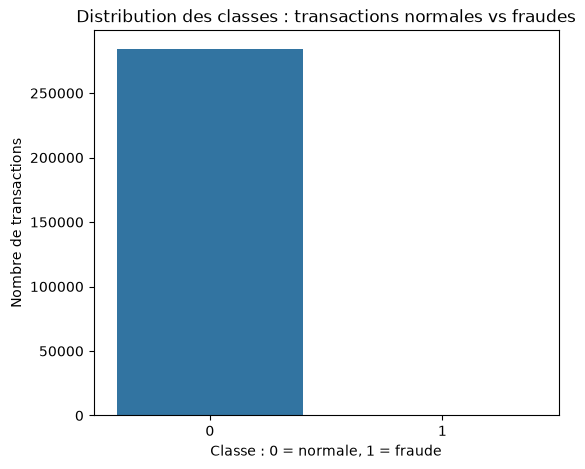

In [ ]:
# 5.1 Distribution de la variable cible
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='Class')
plt.title("Distribution des classes : transactions normales vs fraudes")
plt.xlabel("Classe : 0 = normale, 1 = fraude")
plt.ylabel("Nombre de transactions")
plt.show()

##### Cet histogramme permet de visualiser la répartition des montants des transactions et d'identifier la tendance générale des achats ainsi que la présence d'éventuelles valeurs aberrantes.

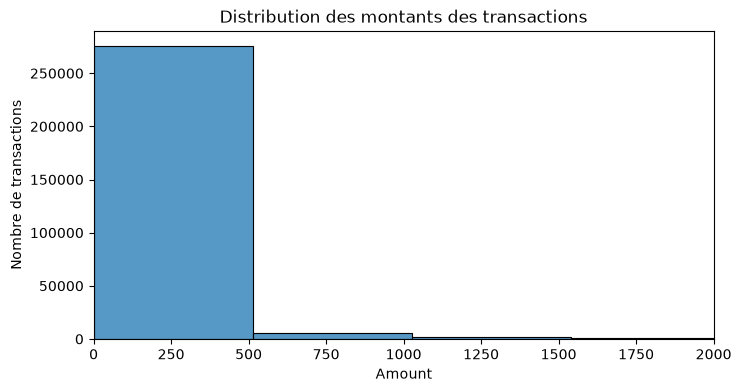

In [22]:
# 5.3 Analyse de Amount
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="Amount", bins=50)
plt.xlim(0,2000)
plt.title("Distribution des montants des transactions")
plt.xlabel("Amount")
plt.ylabel("Nombre de transactions")
plt.show()

La variable `Amount` présente une distribution très asymétrique.  
La majorité des transactions ont des montants faibles ou moyens, tandis que quelques transactions ont des montants très élevés.

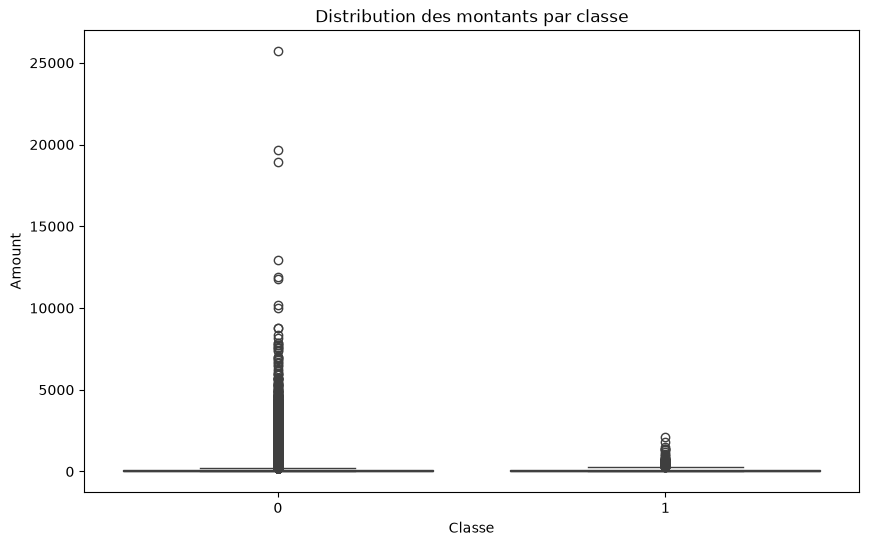

In [28]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, y="Amount", x="Class")
plt.title("Distribution des montants par classe")
plt.xlabel("Classe")
plt.ylabel("Amount")
plt.show()

